# Regresión sobre el Score PHQ-9

En este notebook entrenamos modelos de regresión para **predecir la severidad de la depresión** (score total PHQ-9, rango 0–27) a partir de variables conductuales y demográficas recolectadas mediante **Evaluación Momentánea Ecológica (EMA)**.

A diferencia del análisis fMRI (clasificación binaria MDD/HC), aquí la tarea es regresión: queremos estimar un valor continuo que refleje qué tan severa es la depresión de un paciente.

## Índice
1. [Dataset](#1)
2. [Imports y exploración](#2)
3. [Features del modelo](#3)
4. [Split](#4)
5. [Resultados de regresión](#5)
6. [Scatter plots](#6)
7. [Feature Importance](#7)
8. [Conclusiones](#8)

## 1. Dataset: PHQ-9 Ambulatory Assessment <a id='1'></a>

### ¿Qué es EMA?

La **Evaluación Momentánea Ecológica (EMA)** consiste en recolectar mediciones repetidas de una persona en su vida cotidiana durante un periodo. A diferencia de una encuesta clínica única, EMA captura la variabilidad temporal de los síntomas.

| Característica | Valor |
|---|---|
| Pacientes | 185 |
| Observaciones totales | ~16,150 |
| Duración del seguimiento | 14 días |
| Frecuencia de muestreo | 3 veces al día (mañana, mediodía, noche) |
| Target | `phq_total` = suma de ítems PHQ-9 (0–27) |

### Naturaleza del PHQ-9 en EMA

Los **9 ítems del PHQ-9** (`phq1`–`phq9`) son una evaluación clínica fija por paciente, se respondieron una sola vez al inicio del estudio. Lo que varía diariamente es el **`happiness.score`** (escala de felicidad momentánea).

## 2. Imports y exploración <a id='2'></a>

In [1]:
import json
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

sys.path.append('..')

from src.phq9.data_loader import (
    cargar_datos, preprocesar_features, hacer_split, preparar_regresion
)

FIGURES_DIR = '../results/figures/phq9'
METRICS_DIR = '../results/metrics/phq9'

# cargar y preprocesar
df_raw  = cargar_datos()
df      = preprocesar_features(df_raw)

print(f'\nShape final: {df.shape}')
print(f'Columnas: {list(df.columns)}')

[INFO] Cargando: C:\Codigos\Samsung Innovation\depresion_mdd\data\raw\PHQ-9\Dataset_14-day_AA_depression_symptoms_mood_and_PHQ-9.csv
[INFO] Shape original: (16150, 36)
[INFO] Filas eliminadas sin target: 286
[INFO] Shape tras limpieza: (15864, 18)
[INFO] Features preprocesadas:
  Nulos restantes:
happiness.score    0
phq.day            0
hour               0
period.name        0
sex                0
age                0
dtype: int64

Shape final: (15864, 18)
Columnas: ['user_id', 'phq1', 'phq2', 'phq3', 'phq4', 'phq5', 'phq6', 'phq7', 'phq8', 'phq9', 'age', 'sex', 'q1', 'happiness.score', 'period.name', 'phq.day', 'phq_total', 'hour']


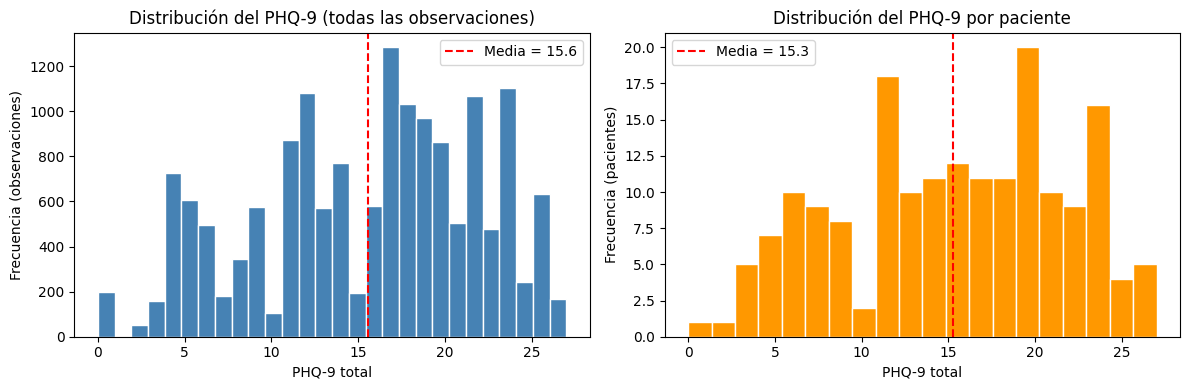

PHQ-9 por paciente: media=15.3, std=6.4, min=0, max=27


In [2]:
# distribución del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histograma por observacion
axes[0].hist(df['phq_total'], bins=28, color='steelblue', edgecolor='white')
axes[0].set_xlabel('PHQ-9 total')
axes[0].set_ylabel('Frecuencia (observaciones)')
axes[0].set_title('Distribución del PHQ-9 (todas las observaciones)')
axes[0].axvline(df['phq_total'].mean(), color='red', linestyle='--',
                label=f'Media = {df["phq_total"].mean():.1f}')
axes[0].legend()

# media por usuario
phq_por_usuario = df.groupby('user_id')['phq_total'].first()
axes[1].hist(phq_por_usuario, bins=20, color='#FF9800', edgecolor='white')
axes[1].set_xlabel('PHQ-9 total')
axes[1].set_ylabel('Frecuencia (pacientes)')
axes[1].set_title('Distribución del PHQ-9 por paciente')
axes[1].axvline(phq_por_usuario.mean(), color='red', linestyle='--',
                label=f'Media = {phq_por_usuario.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'PHQ-9 por paciente: media={phq_por_usuario.mean():.1f}, std={phq_por_usuario.std():.1f}, '
      f'min={phq_por_usuario.min():.0f}, max={phq_por_usuario.max():.0f}')

## 3. Features del modelo <a id='3'></a>

Las features disponibles para predecir `phq_total` son **no clínicas**, no incluimos los ítems PHQ-9 porque conocer la respuesta a los síntomas ya equivale a conocer el score.

| Feature | Descripción | Tipo |
|---|---|---|
| `happiness.score` | Felicidad momentánea reportada (escala 1–4) | Continua, varía por día |
| `phq.day` | Día del estudio (1–14) | Entera |
| `hour` | Hora de la evaluación (0–23) | Entera |
| `period.name` | Período del día (0=mañana, 1=mediodía, 2=noche) | Ordinal |
| `sex` | Sexo del paciente (0=female, 1=male, 2=transgender) | Categórica |
| `age` | Edad del paciente | Continua |

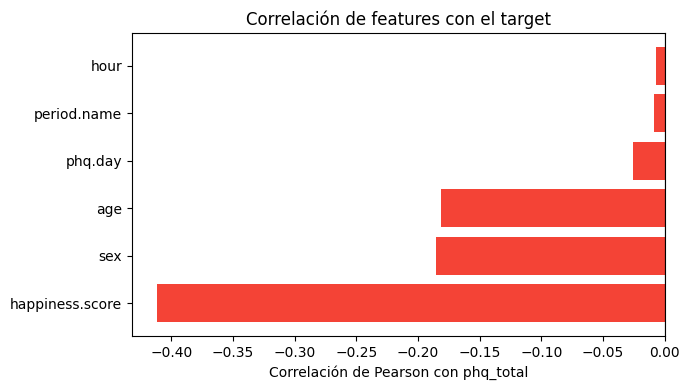

Correlaciones:
happiness.score   -0.4114
sex               -0.1851
age               -0.1811
phq.day           -0.0257
period.name       -0.0087
hour              -0.0074
Name: phq_total, dtype: float64


In [3]:
FEATURES = ['happiness.score', 'phq.day', 'hour', 'period.name', 'sex', 'age']

# correlación de cada feature con phq_total
correlaciones = df[FEATURES + ['phq_total']].corr()['phq_total'].drop('phq_total').sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#F44336' if c < 0 else '#4CAF50' for c in correlaciones]
ax.barh(correlaciones.index, correlaciones.values, color=colores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con phq_total')
ax.set_title('Correlación de features con el target')
plt.tight_layout()
plt.show()

print('Correlaciones:')
print(correlaciones.round(4))

## 4. Split por `user_id` <a id='4'></a>

Una decisión crítica de diseño es **cómo dividir los datos**. Cada paciente tiene ~87 observaciones (16,150 / 185). Si dividimos por filas aleatoriamente, el mismo paciente puede aparecer en train y test y el modelo aprendería el patrón individual de ese paciente, no un patrón generalizable.

La solución es dividir por `user_id`: todos los registros de un paciente van al mismo split.

In [4]:
df_train, df_val, df_test = hacer_split(df)
splits = preparar_regresion(df_train, df_val, df_test)

print(f'\nX_train: {splits["X_train"].shape}')
print(f'X_val:   {splits["X_val"].shape}')
print(f'X_test:  {splits["X_test"].shape}')
print(f'\nPHQ-9 en train: media={splits["y_train"].mean():.1f} ± {splits["y_train"].std():.1f}')
print(f'PHQ-9 en test:  media={splits["y_test"].mean():.1f} ± {splits["y_test"].std():.1f}')

[INFO] Split por user_id (70/15/15):
  Train: 126 usuarios, 11600 filas
  Val:   27 usuarios, 2051 filas
  Test:  27 usuarios, 2213 filas
[INFO] Scaler guardado: C:\Codigos\Samsung Innovation\depresion_mdd\results\models\phq9/scaler_regression.pkl

X_train: (11600, 6)
X_val:   (2051, 6)
X_test:  (2213, 6)

PHQ-9 en train: media=15.2 ± 6.7
PHQ-9 en test:  media=16.7 ± 6.6


## 5. Resultados de regresión <a id='5'></a>

In [5]:
def cargar_metricas_phq9(modelo: str, split: str) -> dict:
    """Carga métricas de regresión desde JSON.

    Args:
        modelo: nombre del modelo (Ridge, SVR, XGB)
        split: 'val' o 'test'

    Returns:
        Diccionario con métricas.
    """
    path = os.path.join(METRICS_DIR, f'metrics_{modelo}_{split}.json')
    with open(path) as f:
        return json.load(f)

modelos = ['Ridge', 'SVR', 'XGB']
filas = []
for m in modelos:
    mt = cargar_metricas_phq9(m, 'test')
    filas.append({'Modelo': m, 'RMSE': mt['rmse'], 'MAE': mt['mae'],
                  'R²': mt['r2'], 'Pearson r': mt['pearson_r']})

df_res = pd.DataFrame(filas).set_index('Modelo')

display(df_res
        .style.background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE'])
        .background_gradient(cmap='RdYlGn', subset=['R²', 'Pearson r'])
        .format('{:.4f}'))

,RMSE,MAE,R²,Pearson r
Modelo,,,,
Ridge,5.8165,4.3688,0.2312,0.4995
SVR,6.3055,5.2277,0.0965,0.3318
XGB,6.3175,4.9493,0.0931,0.3613


**Interpretación de métricas:**

- **RMSE** (Root Mean Squared Error): error promedio en las mismas unidades que el target (puntos PHQ-9). Ridge obtiene RMSE=5.82, lo que significa que el modelo se equivoca ~6 puntos en promedio sobre una escala de 0–27.
- **R²**: proporción de varianza del target explicada por el modelo. Ridge R²=0.23 indica que las 6 features explican el 23% de la variabilidad del PHQ-9.
- **Pearson r = 0.50**: correlación moderada entre predicciones y valores reales. El modelo captura la tendencia general pero con alta dispersión.

## 6. Scatter plots: Real vs Predicho <a id='6'></a>

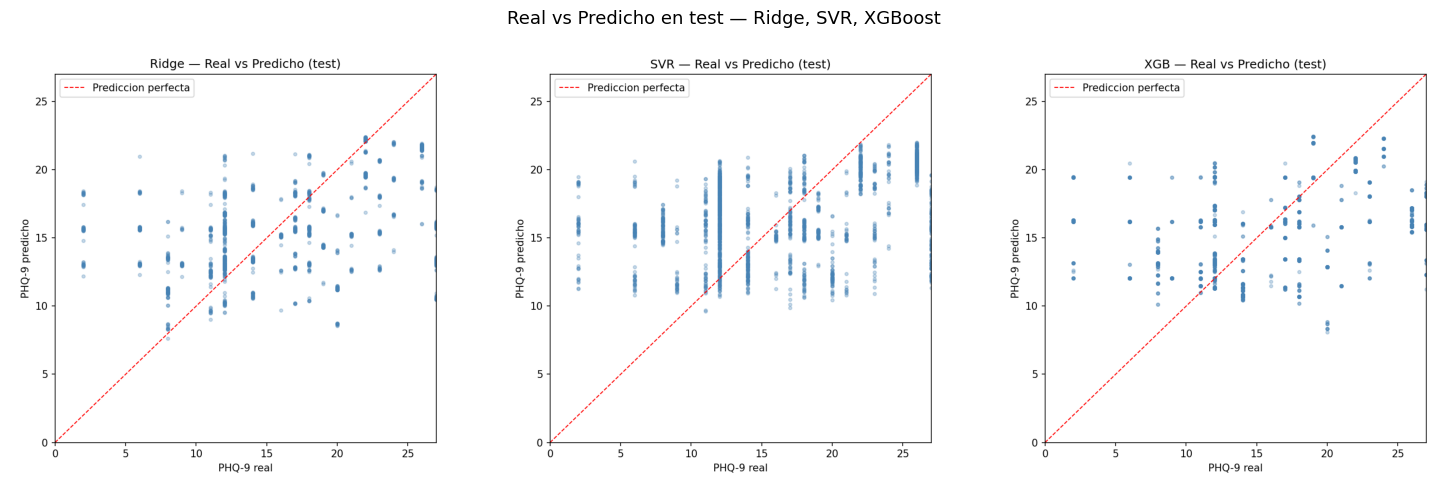

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, modelo in zip(axes, modelos):
    img_path = os.path.join(FIGURES_DIR, f'scatter_{modelo}.png')
    ax.imshow(mpimg.imread(img_path))
    ax.axis('off')

plt.suptitle('Real vs Predicho en test — Ridge, SVR, XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Feature importance (XGBoost) <a id='7'></a>

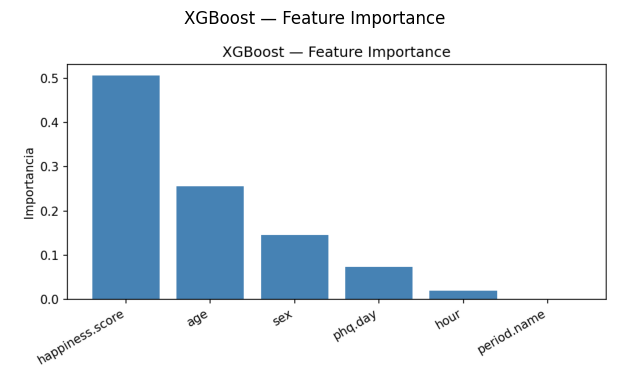

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(mpimg.imread(os.path.join(FIGURES_DIR, 'feature_importance_XGB.png')))
ax.axis('off')
plt.title('XGBoost — Feature Importance')
plt.tight_layout()
plt.show()

## 8. Conclusiones <a id='8'></a>

**1. Ridge es el mejor modelo (RMSE=5.82, R²=0.23, r=0.50).**  
La relación entre las features disponibles y el PHQ-9 es aproximadamente lineal. SVR y XGBoost no superan a Ridge, lo que sugiere que la ganancia de complejidad no está justificada con este conjunto de features.

**2. R²=0.23 es modesto pero explicable.**  
Las features usadas (`happiness.score`, día, hora, período, sexo, edad) son predictores débiles del PHQ-9 porque:
- Los ítems PHQ-9 son fijos por paciente y la mayor fuente de variabilidad es entre pacientes, no dentro de un mismo paciente a lo largo del tiempo.
- El `happiness.score` varía diariamente pero es una medida diferente al PHQ-9 (estado momentáneo vs síntomas clínicos de las últimas 2 semanas).
- Variables clínicas relevantes (diagnóstico previo, medicación, historial) no están disponibles en el dataset.

**3. El split por `user_id` es fundamental.**  
Sin este cuidado, un modelo podría aprender el patrón individual de cada paciente (memorizar sus valores PHQ) y obtener métricas artificialmente altas que no generalizarían a nuevos pacientes.

**4. El modelo tiene utilidad predictiva limitada para uso clínico directo.**  
Un error de ~6 puntos PHQ sobre una escala de 27 es grande. Sin embargo, la correlación de r=0.50 indica que el modelo sí captura parte de la señal real, podría ser útil como herramienta de screening o para detectar tendencias de cambio, no como diagnóstico.